In [28]:
%pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("redwankarimsony/heart-disease-data")

print("Path to dataset files:", path)

Note: you may need to restart the kernel to use updated packages.
Path to dataset files: C:\Users\Raghav\.cache\kagglehub\datasets\redwankarimsony\heart-disease-data\versions\6


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay

In [30]:
df = pd.read_csv("C:/Users/Raghav/.cache/kagglehub/datasets/redwankarimsony/heart-disease-data/versions/6/heart_disease_uci.csv")

In [31]:
print('dataframe:\n',df)

dataframe:
       id  age     sex        dataset               cp  trestbps   chol    fbs  \
0      1   63    Male      Cleveland   typical angina     145.0  233.0   True   
1      2   67    Male      Cleveland     asymptomatic     160.0  286.0  False   
2      3   67    Male      Cleveland     asymptomatic     120.0  229.0  False   
3      4   37    Male      Cleveland      non-anginal     130.0  250.0  False   
4      5   41  Female      Cleveland  atypical angina     130.0  204.0  False   
..   ...  ...     ...            ...              ...       ...    ...    ...   
915  916   54  Female  VA Long Beach     asymptomatic     127.0  333.0   True   
916  917   62    Male  VA Long Beach   typical angina       NaN  139.0  False   
917  918   55    Male  VA Long Beach     asymptomatic     122.0  223.0   True   
918  919   58    Male  VA Long Beach     asymptomatic       NaN  385.0   True   
919  920   62    Male  VA Long Beach  atypical angina     120.0  254.0  False   

              r

In [32]:
print("description of data : \n",df.describe())

description of data : 
                id         age    trestbps        chol      thalch     oldpeak  \
count  920.000000  920.000000  861.000000  890.000000  865.000000  858.000000   
mean   460.500000   53.510870  132.132404  199.130337  137.545665    0.878788   
std    265.725422    9.424685   19.066070  110.780810   25.926276    1.091226   
min      1.000000   28.000000    0.000000    0.000000   60.000000   -2.600000   
25%    230.750000   47.000000  120.000000  175.000000  120.000000    0.000000   
50%    460.500000   54.000000  130.000000  223.000000  140.000000    0.500000   
75%    690.250000   60.000000  140.000000  268.000000  157.000000    1.500000   
max    920.000000   77.000000  200.000000  603.000000  202.000000    6.200000   

               ca         num  
count  309.000000  920.000000  
mean     0.676375    0.995652  
std      0.935653    1.142693  
min      0.000000    0.000000  
25%      0.000000    0.000000  
50%      0.000000    1.000000  
75%      1.000000    2

In [33]:
print("information of the data : \n",df.info())

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB
information of the data : 
 None


In [34]:
print('datatypes:\n',df.dtypes)

datatypes:
 id            int64
age           int64
sex             str
dataset         str
cp              str
trestbps    float64
chol        float64
fbs          object
restecg         str
thalch      float64
exang        object
oldpeak     float64
slope           str
ca          float64
thal            str
num           int64
dtype: object


In [35]:
print("missing values in data : \n",df.isnull().sum())

missing values in data : 
 id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [36]:
df['ca'].unique()

array([ 0.,  3.,  2.,  1., nan])

In [37]:
df['thal'].unique()

<StringArray>
['fixed defect', 'normal', 'reversable defect', nan]
Length: 4, dtype: str

In [38]:
len(df.loc[(df['ca'] == '?') | (df['thal'] == '?')])


0

In [39]:
df.loc[(df["ca"] == "?") | (df["thal"] == "?")]

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num


In [40]:
len(df)

920

In [41]:
df_no_missing = df.loc[(df['ca'] != '?') | (df['thal'] != '?')]

In [42]:
df_no_missing['thal'].unique()

<StringArray>
['fixed defect', 'normal', 'reversable defect', nan]
Length: 4, dtype: str

In [43]:
df_no_missing["ca"].unique()

array([ 0.,  3.,  2.,  1., nan])

In [44]:
df['cp'].unique()

<StringArray>
['typical angina', 'asymptomatic', 'non-anginal', 'atypical angina']
Length: 4, dtype: str

In [45]:
pd.get_dummies(df,columns=['cp']).head()

,id,age,sex,dataset,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,cp_asymptomatic,cp_atypical angina,cp_non-anginal,cp_typical angina
0,1,63,Male,Cleveland,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,False,False,False,True
1,2,67,Male,Cleveland,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,True,False,False,False
2,3,67,Male,Cleveland,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,True,False,False,False
3,4,37,Male,Cleveland,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,False,False,True,False
4,5,41,Female,Cleveland,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,False,True,False,False


In [46]:
df_encoded = pd.get_dummies(df,columns = ['cp','restecg','slope','thal'])
df_encoded.head()

,id,age,sex,dataset,trestbps,chol,fbs,thalch,exang,oldpeak,...,cp_typical angina,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,slope_downsloping,slope_flat,slope_upsloping,thal_fixed defect,thal_normal,thal_reversable defect
0,1,63,Male,Cleveland,145.0,233.0,True,150.0,False,2.3,...,True,True,False,False,True,False,False,True,False,False
1,2,67,Male,Cleveland,160.0,286.0,False,108.0,True,1.5,...,False,True,False,False,False,True,False,False,True,False
2,3,67,Male,Cleveland,120.0,229.0,False,129.0,True,2.6,...,False,True,False,False,False,True,False,False,False,True
3,4,37,Male,Cleveland,130.0,250.0,False,187.0,False,3.5,...,False,False,True,False,True,False,False,False,True,False
4,5,41,Female,Cleveland,130.0,204.0,False,172.0,False,1.4,...,False,True,False,False,False,False,True,False,True,False


In [47]:
x = df_encoded.drop(columns=["num"]).copy()
y = df_encoded["num"].copy()

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

In [48]:
clf_dt = DecisionTreeClassifier(random_state = 42)
x_train_model = pd.get_dummies(x_train, columns=["sex", "dataset"], drop_first=True)
x_train_model = x_train_model.apply(pd.to_numeric, errors="coerce")
x_train_model = x_train_model.fillna(x_train_model.median(numeric_only=True)).fillna(0)

clf_dt = clf_dt.fit(x_train_model, y_train)

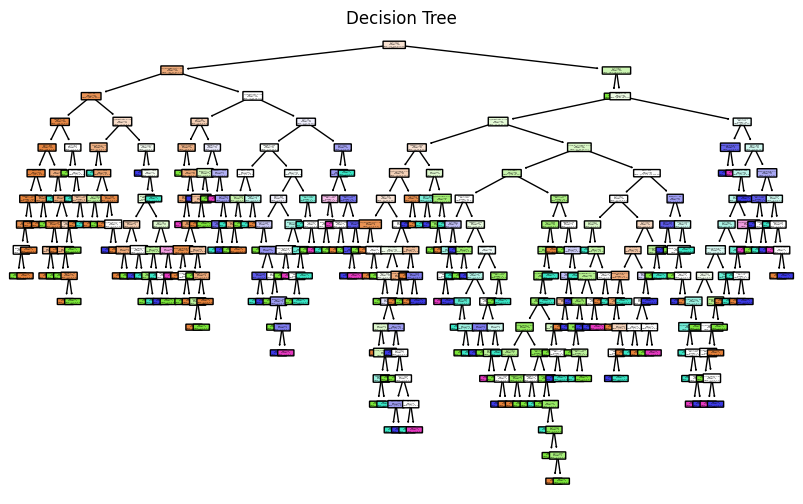

In [49]:
plt.figure(figsize=(10,6))

plot_tree(
    clf_dt,
    filled=True,
    rounded=True,
    class_names=[str(c) for c in clf_dt.classes_],
    feature_names=x_train_model.columns
)
plt.title("Decision Tree")
plt.show()

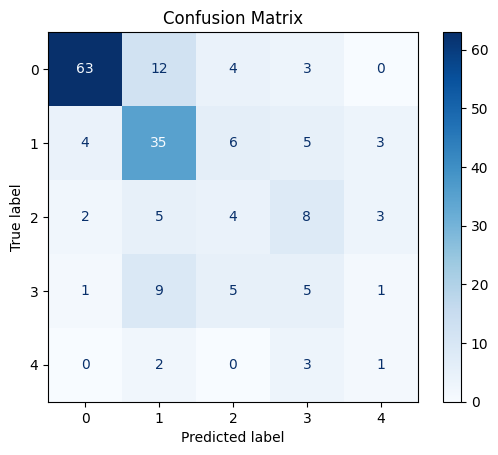

In [50]:
x_test_model = pd.get_dummies(x_test, columns=["sex", "dataset"], drop_first=True)
x_test_model = x_test_model.reindex(columns=x_train_model.columns, fill_value=0)
x_test_model = x_test_model.apply(pd.to_numeric, errors="coerce")
x_test_model = x_test_model.fillna(x_train_model.median(numeric_only=True)).fillna(0)

ConfusionMatrixDisplay.from_estimator(
    clf_dt,
    x_test_model,
    y_test,
    display_labels=[str(c) for c in clf_dt.classes_],
    cmap="Blues"
)
plt.title("Confusion Matrix")
plt.show()


In [51]:
ccp_path = clf_dt.cost_complexity_pruning_path(x_train_model, y_train)
ccp_alphas = ccp_path.ccp_alphas[:-1]

clf_dts = []

for ccp_alpha in ccp_alphas:
    pruned_clf = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    pruned_clf.fit(x_train_model, y_train)
    clf_dts.append(pruned_clf)

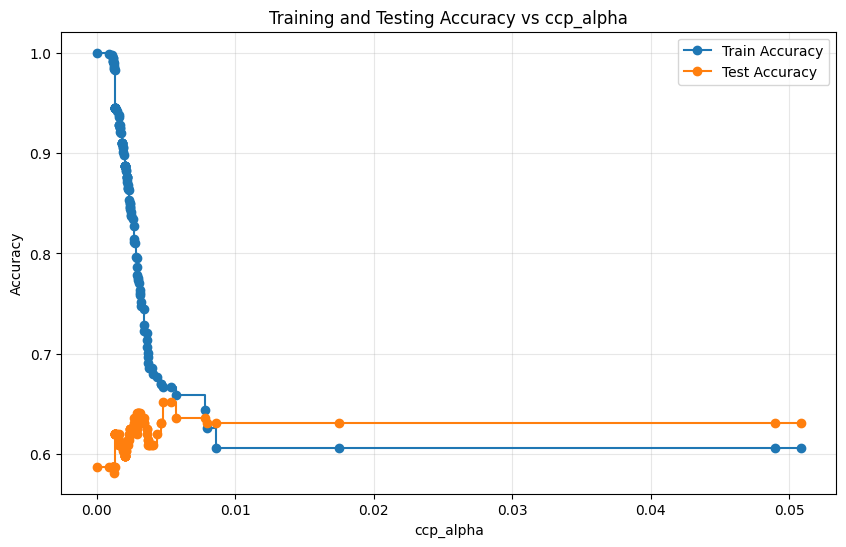

In [52]:
train_scores = [model.score(x_train_model, y_train) for model in clf_dts]
test_scores = [model.score(x_test_model, y_test) for model in clf_dts]

plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, train_scores, marker="o", label="Train Accuracy", drawstyle="steps-post")
plt.plot(ccp_alphas, test_scores, marker="o", label="Test Accuracy", drawstyle="steps-post")
plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("Training and Testing Accuracy vs ccp_alpha")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Best ccp_alpha: 0.003736
Best CV mean accuracy: 0.6196


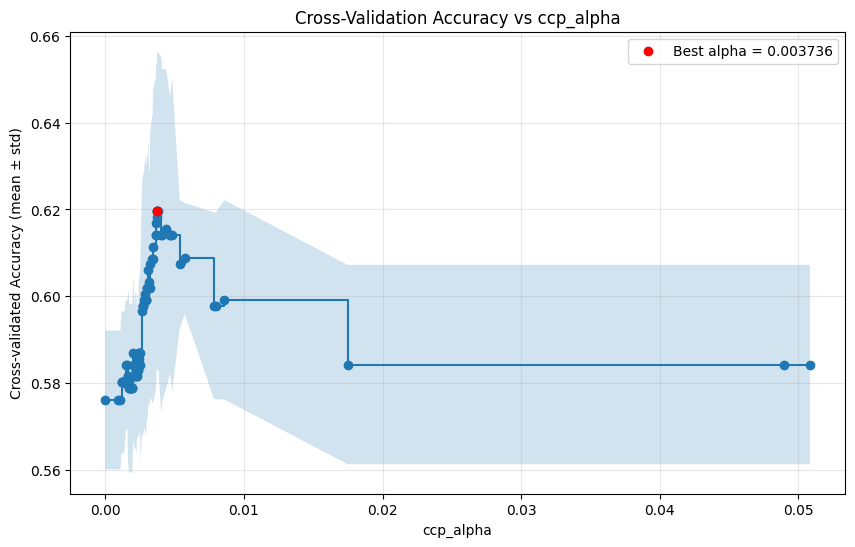

In [53]:
# Cross-validation over pruning alphas to find the best ccp_alpha
alphas_to_test = np.unique(ccp_alphas)

cv_mean_scores = []
cv_std_scores = []

for alpha in alphas_to_test:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    scores = cross_val_score(model, x_train_model, y_train, cv=5, scoring="accuracy")
    cv_mean_scores.append(scores.mean())
    cv_std_scores.append(scores.std())

cv_results = pd.DataFrame(
    {
        "ccp_alpha": alphas_to_test,
        "cv_mean_accuracy": cv_mean_scores,
        "cv_std_accuracy": cv_std_scores,
    }
)

best_idx = cv_results["cv_mean_accuracy"].idxmax()
best_alpha = cv_results.loc[best_idx, "ccp_alpha"]
best_score = cv_results.loc[best_idx, "cv_mean_accuracy"]

print(f"Best ccp_alpha: {best_alpha:.6f}")
print(f"Best CV mean accuracy: {best_score:.4f}")

# Plot CV accuracy vs alpha
plt.figure(figsize=(10, 6))
plt.plot(
    cv_results["ccp_alpha"],
    cv_results["cv_mean_accuracy"],
    marker="o",
    drawstyle="steps-post",
)
plt.fill_between(
    cv_results["ccp_alpha"],
    cv_results["cv_mean_accuracy"] - cv_results["cv_std_accuracy"],
    cv_results["cv_mean_accuracy"] + cv_results["cv_std_accuracy"],
    alpha=0.2,
)
plt.scatter(
    [best_alpha],
    [best_score],
    color="red",
    label=f"Best alpha = {best_alpha:.6f}",
    zorder=3,
)

plt.xlabel("ccp_alpha")
plt.ylabel("Cross-validated Accuracy (mean ± std)")
plt.title("Cross-Validation Accuracy vs ccp_alpha")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Final tree ccp_alpha: 0.003736
Train accuracy: 0.6970
Test accuracy: 0.6141


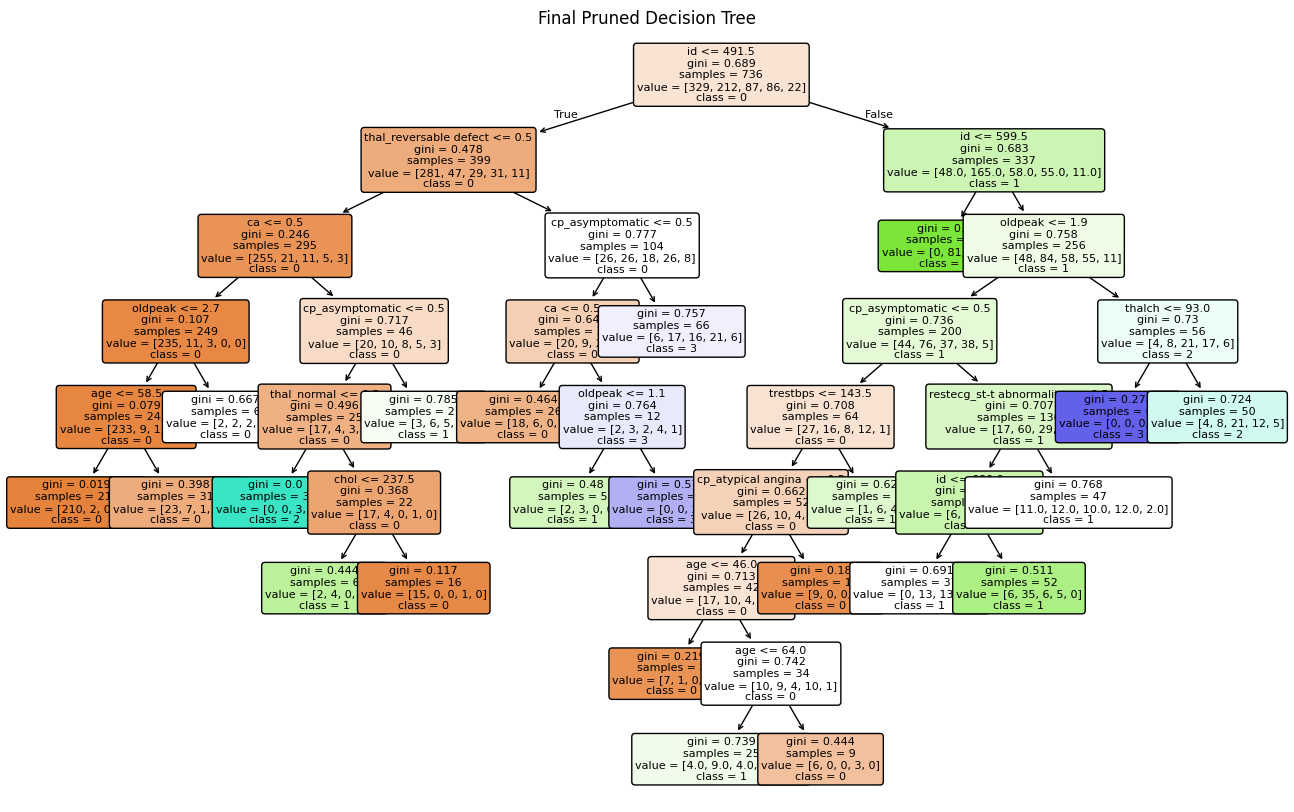

In [54]:
# Final pruned decision tree using the best alpha from cross-validation
final_clf = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
final_clf.fit(x_train_model, y_train)

print(f"Final tree ccp_alpha: {best_alpha:.6f}")
print(f"Train accuracy: {final_clf.score(x_train_model, y_train):.4f}")
print(f"Test accuracy: {final_clf.score(x_test_model, y_test):.4f}")

plt.figure(figsize=(16, 10))
plot_tree(
    final_clf,
    filled=True,
    rounded=True,
    feature_names=x_train_model.columns,
    class_names=[str(c) for c in final_clf.classes_],
    fontsize=8
)
plt.title("Final Pruned Decision Tree")
plt.show()